
BURST MODE SINGLE PULSE CAPTURE

Hardware connections:
Pulser CH1 → Scope CH1 (main pulse)
Pulser TRIG OUT → Scope CH4 (trigger)
Connected to Pulser: ACTIVE TECHNOLOGIES,AT-PULSE-RIDER-PG1072,00000001,SCPI:99.0,SV:1.0.0.0
Connected to Scope: TEKTRONIX,TDS6604,B010466,CF:91.1CT FV:2.5.3

CONFIGURING MULTI-PULSE BURST MODE (2 pulses)

1. Setting pulse mode:
   Mode: DOUble (2 pulses)

2. Setting shared parameters:
   Amplitude: 0.2 V (0 to 0.2V)
   Polarity: normal
   (Both apply to ALL pulses)

   Pulse 1:
      Width: 1 ns
      Delay: 100 ns

   Pulse 2:
      Width: 1 ns
      Delay: 200 ns

4. Burst mode:
   All 2 pulses fire per trigger

5. Trigger output:
   0.9V sync output

6. Starting:



CONFIGURING MULTI-PULSE BURST MODE (1 pulses)

1. Setting pulse mode:
   Mode: SINgle (1 pulse)

2. Setting shared parameters:
   Amplitude: 0.2 V (0 to 0.2V)
   Polarity: inverted
   (Both apply to ALL pulses)

   Pulse 1:
      Width: 1 ns
      Delay: 10 ns

4. Burst mode:
   All 1 pulses 

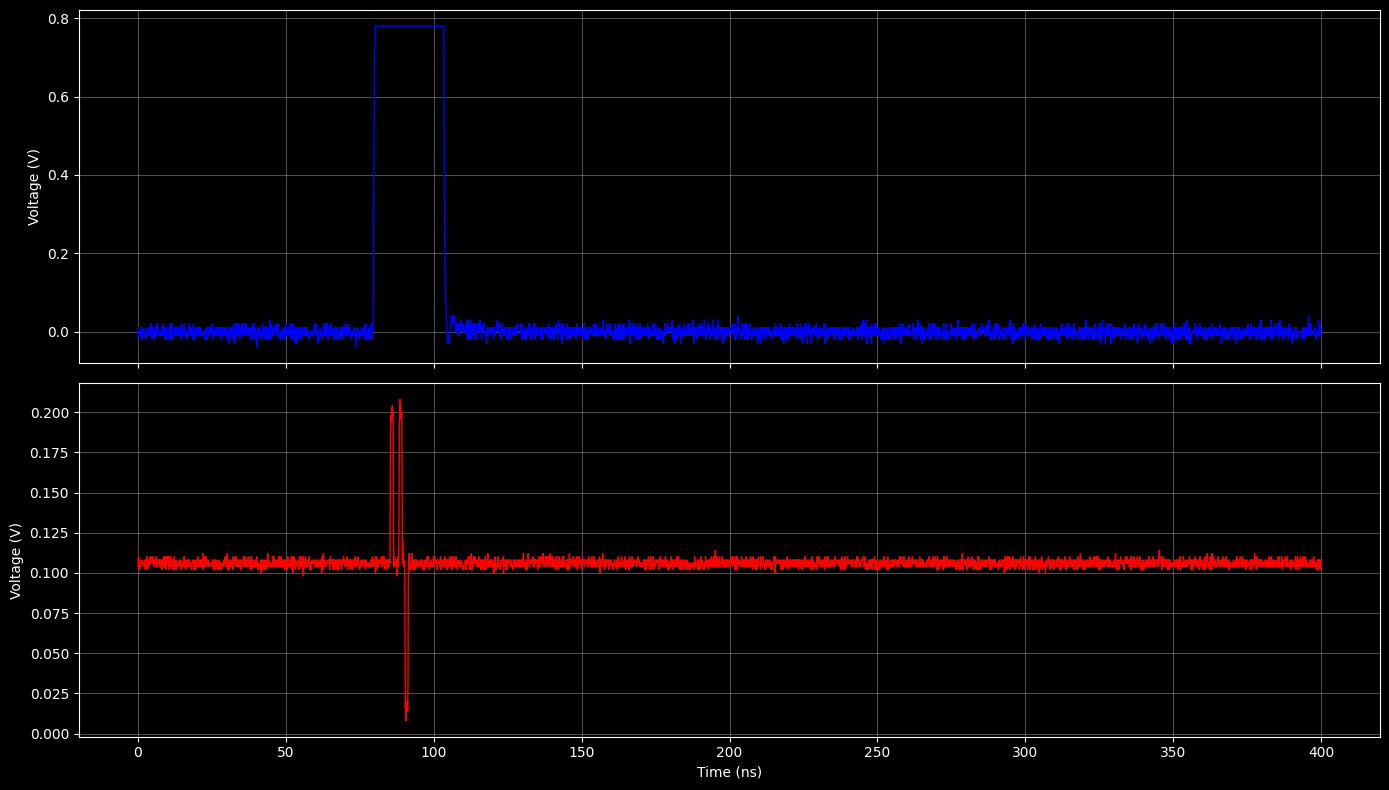

CLEANUP
Pulser connection closed


In [2]:
import pyvisa
import time
import numpy as np
import matplotlib.pyplot as plt

class BNC765Controller:
    def __init__(self, ip_address='169.254.125.69'):
        """Connect to BNC 765 Pulse Generator"""
        self.rm = pyvisa.ResourceManager()
        self.pulser = self.rm.open_resource(f'TCPIP::{ip_address}::INSTR')
        self.pulser.timeout = 10000
        idn = self.pulser.query('*IDN?')
        print(f"Connected to Pulser: {idn.strip()}")

    def setup_burst(self, channel=1, width_ns=100, voltage=1.0,
                        delay_ns=50, inverted=False):
        """
        Setup single-pulse burst mode with delay

        Parameters:
        -----------
        channel : int
            Output channel (1-4)
        width_ns : float
            Pulse width in nanoseconds
        voltage : float
            Pulse amplitude in volts (0 to voltage)
        delay_ns : float
            Pulse delay in nanoseconds (allows trigger to settle before pulse)
        inverted : bool
            False: 0V→voltage, True: voltage→0V
        """
        print(f"\n{'='*60}")
        print(f"CONFIGURING BURST MODE")
        print(f"{'='*60}\n")

        self.pulser.write('PULSEGENCONTROL:STOP')
        self.pulser.write(f'OUTPUT{channel}:STATE OFF')
        time.sleep(0.3)

        print("1. Pulse parameters:")
        self.pulser.write(f'SOURCE{channel}:VOLTAGE:LEVEL {voltage}')
        self.pulser.write(f'SOURCE{channel}:VOLTAGE:OFFSET {voltage/2}')
        self.pulser.write(f'SOURCE{channel}:PULSE:WIDTH {width_ns}E-9')

        # KEY: Add delay so scope has time to trigger before pulse arrives
        self.pulser.write(f'SOURCE{channel}:PULSE:DELAY {delay_ns}E-9')

        self.pulser.write(f'SOURCE{channel}:FREQUENCY 1000000')  # Doesn't matter in burst

        inv_state = 'ON' if inverted else 'OFF'
        self.pulser.write(f'SOURCE{channel}:INV {inv_state}')

        polarity = "inverted" if inverted else "normal"
        print(f"   Width: {width_ns} ns")
        print(f"   Delay: {delay_ns} ns (critical for scope triggering!)")
        print(f"   Amplitude: {voltage} V ({polarity})")

        print("\n2. Burst mode:")
        self.pulser.write(f'SOURCE{channel}:BURST:NCYCLES 1')
        self.pulser.write('TRIGGER:MODE BURST')
        self.pulser.write('TRIGGER:SOURCE MANUAL')

        burst_cycles = self.pulser.query(f'SOURCE{channel}:BURST:NCYCLES?').strip()
        trig_mode = self.pulser.query('TRIGGER:MODE?').strip()
        print(f"   Cycles per trigger: {burst_cycles}")
        print(f"   Mode: {trig_mode}")

        print("\n3. Trigger output:")
        self.pulser.write('TRIGGER:OUTPUT:AMPLITUDE 0.9')
        self.pulser.write('TRIGGER:OUTPUT:POLARITY POSITIVE')
        self.pulser.write(f'TRIGGER:OUTPUT:SOURCE OUT{channel}')
        print(f"   0.9V sync output (fires {delay_ns}ns before pulse)")

        print("\n4. Starting:")
        self.pulser.write(f'OUTPUT{channel}:STATE ON')
        self.pulser.write('PULSEGENCONTROL:START')
        time.sleep(0.5)

        print(f"   ✓ Armed for single-pulse burst")
        print(f"\n{'='*60}\n")

    def setup_multi_pulse_burst(self, channel=1, voltage=1.0, capturewidth_ns=100,
                                inverted=False, pulses=None):
        """
        Setup multi-pulse burst mode with independent pulse parameters

        NOTE: All pulses share the same amplitude and polarity.
              Only width and delay are independent per pulse.

        Parameters:
        -----------
        channel : int
            Output channel (1-4)
        voltage : float
            Amplitude for ALL pulses (shared)
        inverted : bool
            Polarity for ALL pulses (shared)
        pulses : list of dict
            List of pulse definitions. Each dict contains:
            - 'width_ns': pulse width in nanoseconds
            - 'delay_ns': pulse delay in nanoseconds

        Example:
        --------
        pulses = [
            {'width_ns': 100, 'delay_ns': 0},       # First pulse at t=0
            {'width_ns': 200, 'delay_ns': 500},     # Second pulse at t=500ns
            {'width_ns': 150, 'delay_ns': 1000},    # Third pulse at t=1000ns
        ]
        """
        if pulses is None:
            pulses = [{'width_ns': 100, 'delay_ns': 50}]

        num_pulses = len(pulses)

        if num_pulses < 1 or num_pulses > 4:
            raise ValueError("Must specify 1-4 pulses")

        print(f"\n{'='*60}")
        print(f"CONFIGURING MULTI-PULSE BURST MODE ({num_pulses} pulses)")
        print(f"{'='*60}\n")

        self.pulser.write('PULSEGENCONTROL:STOP')
        self.pulser.write(f'OUTPUT{channel}:STATE OFF')
        time.sleep(0.3)

        # Set pulse mode based on number of pulses
        pulse_mode_map = {1: 'SIN', 2: 'DOU', 3: 'TRI', 4: 'QUAD'}
        pulse_mode = pulse_mode_map[num_pulses]

        print(f"1. Setting pulse mode:")
        self.pulser.write(f'OUTPUT{channel}:PULSE:MODE {pulse_mode}')
        time.sleep(0.2)

        try:
            actual_mode = self.pulser.query(f'OUTPUT{channel}:PULSE:MODE?').strip()
            print(f"   Mode: {actual_mode} ({num_pulses} pulse{'s' if num_pulses > 1 else ''})")
        except:
            print(f"   Mode: {pulse_mode} ({num_pulses} pulse{'s' if num_pulses > 1 else ''})")

        # Set SHARED amplitude and polarity for all pulses
        print(f"\n2. Setting shared parameters:")
        self.pulser.write(f'SOURCE{channel}:VOLTAGE:LEVEL {voltage}')
        self.pulser.write(f'SOURCE{channel}:VOLTAGE:OFFSET {voltage/2}')

        inv_state = 'ON' if inverted else 'OFF'
        self.pulser.write(f'SOURCE{channel}:INV {inv_state}')

        polarity = "inverted" if inverted else "normal"
        print(f"   Amplitude: {voltage} V (0 to {voltage}V)")
        print(f"   Polarity: {polarity}")
        print(f"   (Both apply to ALL pulses)")

        # Set output impedance to 50 ohm
        self.pulser.write(f'SOUR{channel}:LOAD:IMP 50')
        # print(f"   Output impedance: 50Ω")

        # Configure each pulse (width and delay only)
        # print(f"\n3. Configuring individual pulse timing:")

        for i, pulse in enumerate(pulses):
            pulse_num = i + 1
            width_ns = pulse.get('width_ns', 100)
            delay_ns = pulse.get('delay_ns', 0)

            print(f"\n   Pulse {pulse_num}:")

            pulse_prefix = f'SOURCE{channel}:PULSE{pulse_num}'

            # Width
            self.pulser.write(f'{pulse_prefix}:WIDTH {width_ns}E-9')
            print(f"      Width: {width_ns} ns")

            # Delay
            self.pulser.write(f'{pulse_prefix}:DELAY {delay_ns}E-9')
            print(f"      Delay: {delay_ns} ns")

        # Set frequency
        freq_hz = 1/(capturewidth_ns)
        self.pulser.write(f'SOURCE{channel}:FREQUENCY {freq_hz}')

        print("\n4. Burst mode:")
        self.pulser.write(f'SOURCE{channel}:BURST:NCYCLES 1')
        self.pulser.write('TRIGGER:MODE BURST')
        self.pulser.write('TRIGGER:SOURCE MANUAL')
        print(f"   All {num_pulses} pulses fire per trigger")

        print("\n5. Trigger output:")
        self.pulser.write('TRIGGER:OUTPUT:AMPLITUDE 0.9')
        self.pulser.write('TRIGGER:OUTPUT:POLARITY POSITIVE')
        self.pulser.write(f'TRIGGER:OUTPUT:SOURCE OUT{channel}')
        print(f"   0.9V sync output")

        print("\n6. Starting:")
        self.pulser.write(f'OUTPUT{channel}:STATE ON')
        self.pulser.write('PULSEGENCONTROL:START')
        time.sleep(0.5)

        print(f"\n{'='*60}\n")

    def trigger(self):
        """Trigger a single burst"""
        self.pulser.write('*TRG')

    def stop(self, channel=1):
        """Stop pulse generator"""
        self.pulser.write(f'OUTPUT{channel}:STATE OFF')
        self.pulser.write('PULSEGENCONTROL:STOP')

    def stop_dual_channel(self):
        """Stop both channels"""
        self.pulser.write('OUTPUT1:STATE OFF')
        self.pulser.write('OUTPUT2:STATE OFF')
        self.pulser.write('PULSEGENCONTROL:STOP')

    def close(self):
        """Close connection"""
        self.pulser.close()
        print("Pulser connection closed")



class TDS6604Controller:
    def __init__(self, gpib_address='GPIB0::2::INSTR'):
        """Connect to scope"""
        self.rm = pyvisa.ResourceManager()
        self.scope = self.rm.open_resource(gpib_address)
        self.scope.timeout = 30000
        idn = self.scope.query('*IDN?')
        print(f"Connected to Scope: {idn.strip()}")
        self.scope.write('*CLS')

    def setup_for_burst_capture(self, signal_channel=1, trigger_channel=4,
                            pulse_voltage=1.0, pulse_width_ns=100,
                            pulse_delay_ns=50, record_length=10000):
        """
        Setup scope to capture burst mode pulse

        Parameters:
        -----------
        signal_channel : int
            Channel with pulse signal
        trigger_channel : int
            Channel with trigger signal
        pulse_voltage : float
            Expected pulse amplitude
        pulse_width_ns : float
            Expected pulse width in nanoseconds
        pulse_delay_ns : float
            Pulse delay in nanoseconds
        """
        print(f"\n{'='*60}")
        print(f"CONFIGURING OSCILLOSCOPE")
        print(f"{'='*60}\n")

        # Signal channel
        print(f"Signal channel (CH{signal_channel}):")
        self.scope.write(f'SELECT:CH{signal_channel} ON')
        self.scope.write(f'CH{signal_channel}:COUPLING DC')
        v_scale = pulse_voltage / 4
        self.scope.write(f'CH{signal_channel}:SCALE {v_scale}')
        self.scope.write(f'CH{signal_channel}:POSITION -2')
        print(f"{v_scale} V/div, position -2")

        # Trigger channel
        print(f"\nTrigger channel (CH{trigger_channel}):")
        self.scope.write(f'SELECT:CH{trigger_channel} ON')
        self.scope.write(f'CH{trigger_channel}:COUPLING DC')
        self.scope.write(f'CH{trigger_channel}:SCALE 0.25')
        self.scope.write(f'CH{trigger_channel}:POSITION 2')
        print(f"0.25 V/div, position +2")

        # Set record length BEFORE acquisition setup
        print(f"\nRecord length:")
        self.scope.write(f'HORIZONTAL:RECORDLENGTH {record_length}')
        actual_length = int(float(self.scope.query('HORIZONTAL:RECORDLENGTH?').strip()))

        # Timebase - show delay + pulse + some margin
        print(f"\nTimebase:")
        total_time_ns = (pulse_delay_ns + pulse_width_ns)   # set capture length
        h_scale = total_time_ns * 1e-9 / 10
        self.scope.write(f'HORIZONTAL:MAIN:SCALE {h_scale}')
        actual = float(self.scope.query('HORIZONTAL:MAIN:SCALE?').strip())
        print(f"{actual*1e9:.1f} ns/div ({actual*10*1e9:.0f} ns total)")

        # Trigger setup
        print(f"\nTrigger:")
        self.scope.write('TRIGGER:A:TYPE EDGE')
        self.scope.write(f'TRIGGER:A:EDGE:SOURCE CH{trigger_channel}')
        self.scope.write('TRIGGER:A:EDGE:SLOPE RISE')
        self.scope.write(f'TRIGGER:A:LEVEL:CH{trigger_channel} 0.45')
        self.scope.write('TRIGGER:A:MODE NORMAL')
        self.scope.write('HORIZONTAL:MAIN:POSITION 20')  # Trigger near left to see delay
        print(f"Trigger on CH{trigger_channel} at 0.45V")
        print(f"Trigger position at 20% (see pre-trigger + delay + pulse)")

        # Acquisition
        print(f"\nAcquisition:")
        self.scope.write('ACQUIRE:STOPAFTER SEQUENCE')
        self.scope.write('ACQUIRE:MODE SAMPLE')

        print(f"\n{'='*60}\n")

    def arm(self):
        """Arm scope for single capture"""
        print("Arming scope...")
        self.scope.write('ACQUIRE:STATE RUN')
        time.sleep(0.3)
        print("Scope armed and waiting for trigger\n")

    def check_triggered(self, timeout=2):
        """Check if scope has triggered"""
        start = time.time()
        while time.time() - start < timeout:
            state = int(self.scope.query('ACQUIRE:STATE?').strip())
            if state == 0:
                return True
            time.sleep(0.05)
        return False

    def get_waveform(self, channel=1):
        """Retrieve waveform data"""
        self.scope.write(f'DATA:SOURCE CH{channel}')
        self.scope.write('DATA:ENCDG RIBINARY')
        self.scope.write('DATA:WIDTH 2')

        x_incr = float(self.scope.query('WFMPRE:XINCR?').strip())
        x_zero = float(self.scope.query('WFMPRE:XZERO?').strip())
        y_mult = float(self.scope.query('WFMPRE:YMULT?').strip())
        y_zero = float(self.scope.query('WFMPRE:YZERO?').strip())
        y_off = float(self.scope.query('WFMPRE:YOFF?').strip())

        self.scope.write('CURVE?')
        raw_data = self.scope.read_raw()

        header_len = 2 + int(chr(raw_data[1]))
        byte_count = int(raw_data[2:header_len].decode('ascii'))
        data_bytes = raw_data[header_len:header_len + byte_count]

        voltage_raw = np.frombuffer(data_bytes, dtype=np.dtype('>i2'))
        voltage = (voltage_raw - y_off) * y_mult + y_zero
        time_array = np.arange(len(voltage)) * x_incr + x_zero

        return {'time': time_array, 'voltage': voltage, 'channel': channel}

    def plot_dual_channel(self, ch1_data, ch4_data,
                         filename='burst_mode_capture.png'):
        """Plot both signal and trigger channels with timing annotations"""
        print("\nPlotting...")

        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

        # CH4 - Trigger
        ax1.plot(ch4_data['time']*1e9, ch4_data['voltage'], 'b-', linewidth=1)
        ax1.set_ylabel('Voltage (V)')
        ax1.grid(True, alpha=0.3)

        # CH1 - Signal
        ax2.plot(ch1_data['time']*1e9, ch1_data['voltage'], 'r-', linewidth=1)

        ax2.set_xlabel('Time (ns)')
        ax2.set_ylabel('Voltage (V)')
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig(filename, dpi=150)
        print(f"✓ Saved to {filename}\n")
        plt.show()

    def close(self):
        """Close connection"""
        self.scope.close()


def main():
    """Burst mode single pulse capture"""

    print("\n" + "="*60)
    print("BURST MODE SINGLE PULSE CAPTURE")
    print("="*60 + "\n")

    print("Hardware connections:")
    print("Pulser CH1 → Scope CH1 (main pulse)")
    print("Pulser TRIG OUT → Scope CH4 (trigger)")

    # Configuration
    # PULSE_WIDTH_NS = 20
    # PULSE_DELAY_NS = 5   # Critical! Gives scope time to trigger
    #

    # Connect
    pulser = BNC765Controller('169.254.125.69') # Berkeley pulser
    # pulser = BNC765Controller('169.254.209.156') #Kepler pulser
    scope = TDS6604Controller('GPIB0::2::INSTR') #Kepler is GPIB 1, berkeley is 2

    # single pulse Setup
    # pulser.setup_burst_mode(
    #     channel=1,
    #     width_ns=PULSE_WIDTH_NS,
    #     voltage=PULSE_VOLTAGE,
    #     delay_ns=PULSE_DELAY_NS,
    #     inverted=False
    # )


    # Simple: all pulses same amplitude and polarity, but different timing
    CAPTURE_WIDTH = 300

    PULSE_VOLTAGE = 0.2
    pulses = [
        # {'width_ns': 3, 'delay_ns': 1},
        {'width_ns': 1, 'delay_ns': 100},
        {'width_ns': 1, 'delay_ns': 200},
    ]

    PULSE_VOLTAGE2 = 0.2
    pulses2 = [
        {'width_ns': 1, 'delay_ns': 10},
        # {'width_ns': 2, 'delay_ns': 5},
        # {'width_ns': 1, 'delay_ns': 10},
    ]

    pulser.setup_multi_pulse_burst(
        channel=1,
        voltage=PULSE_VOLTAGE,
        capturewidth_ns = CAPTURE_WIDTH,
        inverted=False,
        pulses=pulses,
    )

    pulser.setup_multi_pulse_burst(
        channel=2,
        voltage=PULSE_VOLTAGE2,
        capturewidth_ns = CAPTURE_WIDTH,
        inverted=True,
        pulses=pulses2,
    )


    #setup scope
    scope.setup_for_burst_capture(
        signal_channel=1,
        trigger_channel=4,
        pulse_voltage=PULSE_VOLTAGE,
        pulse_width_ns=CAPTURE_WIDTH,
        pulse_delay_ns=5,
        record_length = 5000
    )

    scope.arm()

    # Then trigger pulser
    input("Press Enter to trigger burst...")
    pulser.trigger()

    # Wait for capture
    if scope.check_triggered(timeout=2):

        # Get waveforms
        print("Retrieving waveforms...")
        ch1_data = scope.get_waveform(channel=1)
        print(f"  CH1: {len(ch1_data['voltage'])} points, " +
              f"{ch1_data['voltage'].min():.3f} to {ch1_data['voltage'].max():.3f} V")

        ch4_data = scope.get_waveform(channel=4)
        print(f"  CH4: {len(ch4_data['voltage'])} points, " +
              f"{ch4_data['voltage'].min():.3f} to {ch4_data['voltage'].max():.3f} V\n")

        # Plot
        scope.plot_dual_channel(ch1_data, ch4_data)

    # Cleanup
    print("CLEANUP")
    pulser.stop(channel=1)
    pulser.stop(channel=2)
    pulser.close()
    scope.close()


if __name__ == "__main__":
    main()


MULTI-PULSE TEST WITH SCOPE

Hardware connections:
  1. Pulser CH1 → Scope CH1
  2. Pulser TRIG OUT → Scope CH4

Pulser: ACTIVE TECHNOLOGIES,AT-PULSE-RIDER-PG1072,00000001,SCPI:99.0,SV:1.0.0.0
Scope:  TEKTRONIX,TDS6604,B010466,CF:91.1CT FV:2.5.3

CONFIGURING PULSER (2 PULSES)

1. Setting DOUBLE pulse mode...
   Mode: DOUble

2. Pulse 1:
   100ns, 1V, no delay

3. Pulse 2:
   200ns, 0.5V, 500ns delay

✓ Pulser configured

CONFIGURING SCOPE

1. Channel setup:
   CH1: 0.5 V/div, 50Ω
   CH4: 0.25 V/div, 50Ω

2. Record length:
   10000 points

3. Timebase:
   200 ns/div (2000 ns total)

4. Trigger:
   Trigger on CH4, 0.45V

5. Acquisition:
   Single sequence mode

✓ Scope configured

CAPTURING

Scope armed...
✓ Triggered!

Waiting for capture...
✓ Captured!

Retrieving waveform...
✓ Got 10000 points

Plotting...
✓ Saved to two_pulse_burst.png



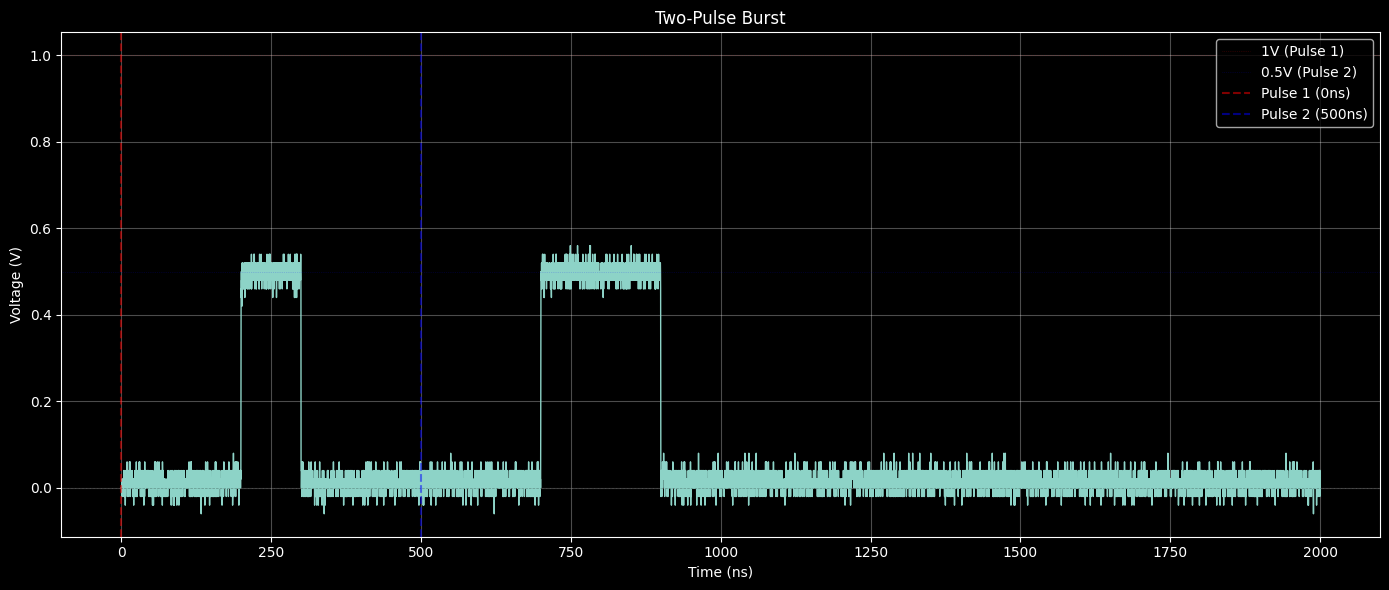

Cleaning up...

✓ Complete!



In [14]:
import pyvisa
import time
import numpy as np
import matplotlib.pyplot as plt

def test_multi_pulse_with_scope():
    """Test multi-pulse with proper scope setup"""

    print("\n" + "="*60)
    print("MULTI-PULSE TEST WITH SCOPE")
    print("="*60 + "\n")

    print("Hardware connections:")
    print("  1. Pulser CH1 → Scope CH1")
    print("  2. Pulser TRIG OUT → Scope CH4")
    input("\nPress Enter when ready...")

    # Connect
    rm = pyvisa.ResourceManager()
    pulser = rm.open_resource('TCPIP::169.254.125.69::INSTR')
    pulser.timeout = 10000
    scope = rm.open_resource('GPIB0::2::INSTR')
    scope.timeout = 30000

    print(f"\nPulser: {pulser.query('*IDN?').strip()}")
    print(f"Scope:  {scope.query('*IDN?').strip()}\n")

    # Setup pulser for 2 pulses
    print("="*60)
    print("CONFIGURING PULSER (2 PULSES)")
    print("="*60 + "\n")

    pulser.write('PULSEGENCONTROL:STOP')
    pulser.write('OUTPUT1:STATE OFF')
    time.sleep(0.3)

    # Set double pulse mode
    print("1. Setting DOUBLE pulse mode...")
    pulser.write('OUTPUT1:PULSE:MODE DOU')
    time.sleep(0.2)
    mode = pulser.query('OUTPUT1:PULSE:MODE?').strip()
    print(f"   Mode: {mode}\n")

    # Configure pulse 1
    print("2. Pulse 1:")
    pulser.write('SOURCE1:PULSE1:WIDTH 100E-9')      # 100ns
    pulser.write('SOURCE1:PULSE1:VOLTAGE:LEVEL 1.0')
    pulser.write('SOURCE1:PULSE1:VOLTAGE:OFFSET 0.5')
    pulser.write('SOURCE1:PULSE1:DELAY 0')           # No delay
    print("   100ns, 1V, no delay")

    # Configure pulse 2
    print("\n3. Pulse 2:")
    pulser.write('SOURCE1:PULSE2:WIDTH 200E-9')      # 200ns
    pulser.write('SOURCE1:PULSE2:VOLTAGE:LEVEL 0.5')
    pulser.write('SOURCE1:PULSE2:VOLTAGE:OFFSET 0.25')
    pulser.write('SOURCE1:PULSE2:DELAY 500E-9')      # 500ns after pulse 1
    print("   200ns, 0.5V, 500ns delay")

    # Set impedance and burst mode
    pulser.write('SOUR1:LOAD:IMP 50')
    pulser.write('SOURCE1:BURST:NCYCLES 1')
    pulser.write('TRIGGER:MODE BURST')
    pulser.write('TRIGGER:SOURCE MANUAL')

    # Trigger output
    pulser.write('TRIGGER:OUTPUT:AMPLITUDE 0.9')
    pulser.write('TRIGGER:OUTPUT:POLARITY POSITIVE')
    pulser.write('TRIGGER:OUTPUT:SOURCE OUT1')

    # Enable
    pulser.write('OUTPUT1:STATE ON')
    pulser.write('PULSEGENCONTROL:START')
    time.sleep(0.5)

    print("\n✓ Pulser configured\n")

    # Setup scope for BOTH pulses
    print("="*60)
    print("CONFIGURING SCOPE")
    print("="*60 + "\n")

    # Calculate total time needed
    # Pulse 1: 0ns to 100ns
    # Pulse 2: 500ns to 700ns
    # Total: need to see at least 0 to 700ns, plus margin
    total_time_ns = 1000  # 1000ns = 1us (includes margin)

    print("1. Channel setup:")
    # CH1 - signal
    scope.write('SELECT:CH1 ON')
    scope.write('CH1:COUPLING DC')
    scope.write('CH1:IMPEDANCE FIFTY')
    scope.write('CH1:SCALE 0.5')  # 0.5 V/div to see both pulses
    scope.write('CH1:POSITION -1')
    print("   CH1: 0.5 V/div, 50Ω")

    # CH4 - trigger
    scope.write('SELECT:CH4 ON')
    scope.write('CH4:COUPLING DC')
    scope.write('CH4:IMPEDANCE FIFTY')
    scope.write('CH4:SCALE 0.25')
    scope.write('CH4:POSITION 2')
    print("   CH4: 0.25 V/div, 50Ω")

    # Record length
    print("\n2. Record length:")
    scope.write('HORIZONTAL:RECORDLENGTH 10000')
    actual_length = int(float(scope.query('HORIZONTAL:RECORDLENGTH?').strip()))
    print(f"   {actual_length} points")

    # Timebase - show full pattern
    print("\n3. Timebase:")
    h_scale = total_time_ns * 1e-9 / 10  # Spread across 10 divisions
    scope.write(f'HORIZONTAL:MAIN:SCALE {h_scale}')
    actual = float(scope.query('HORIZONTAL:MAIN:SCALE?').strip())
    print(f"   {actual*1e9:.0f} ns/div ({actual*10*1e9:.0f} ns total)")

    # Trigger
    print("\n4. Trigger:")
    scope.write('TRIGGER:A:TYPE EDGE')
    scope.write('TRIGGER:A:EDGE:SOURCE CH4')
    scope.write('TRIGGER:A:EDGE:SLOPE RISE')
    scope.write('TRIGGER:A:LEVEL:CH4 0.45')
    scope.write('TRIGGER:A:MODE NORMAL')
    scope.write('HORIZONTAL:MAIN:POSITION 10')  # Trigger at 10% from left
    print("   Trigger on CH4, 0.45V")

    # Acquisition
    print("\n5. Acquisition:")
    scope.write('ACQUIRE:STOPAFTER SEQUENCE')
    scope.write('ACQUIRE:MODE SAMPLE')
    print("   Single sequence mode")

    print("\n✓ Scope configured\n")

    # Capture
    print("="*60)
    print("CAPTURING")
    print("="*60 + "\n")

    scope.write('ACQUIRE:STATE RUN')
    time.sleep(0.3)
    print("Scope armed...")

    input("Press Enter to trigger burst...")
    pulser.write('*TRG')
    print("✓ Triggered!\n")

    # Wait for capture
    print("Waiting for capture...")
    start = time.time()
    while time.time() - start < 3:
        state = int(scope.query('ACQUIRE:STATE?').strip())
        if state == 0:
            print("✓ Captured!\n")
            break
        time.sleep(0.1)
    else:
        print("✗ Timeout\n")
        pulser.write('OUTPUT1:STATE OFF')
        pulser.write('PULSEGENCONTROL:STOP')
        pulser.close()
        scope.close()
        rm.close()
        return

    # Get waveform
    print("Retrieving waveform...")
    scope.write('DATA:SOURCE CH1')
    scope.write('DATA:ENCDG RIBINARY')
    scope.write('DATA:WIDTH 2')
    scope.write('DATA:START 1')
    scope.write(f'DATA:STOP {actual_length}')

    x_incr = float(scope.query('WFMPRE:XINCR?').strip())
    x_zero = float(scope.query('WFMPRE:XZERO?').strip())
    y_mult = float(scope.query('WFMPRE:YMULT?').strip())
    y_zero = float(scope.query('WFMPRE:YZERO?').strip())
    y_off = float(scope.query('WFMPRE:YOFF?').strip())

    scope.write('CURVE?')
    raw_data = scope.read_raw()

    header_len = 2 + int(chr(raw_data[1]))
    byte_count = int(raw_data[2:header_len].decode('ascii'))
    data_bytes = raw_data[header_len:header_len + byte_count]

    voltage_raw = np.frombuffer(data_bytes, dtype=np.dtype('>i2'))
    voltage = (voltage_raw - y_off) * y_mult + y_zero
    time_array = np.arange(len(voltage)) * x_incr + x_zero

    print(f"✓ Got {len(voltage)} points\n")

    # Plot
    print("Plotting...")
    plt.figure(figsize=(14, 6))
    plt.plot(time_array*1e9, voltage, linewidth=1)
    plt.axhline(y=0, color='k', linestyle='--', linewidth=0.5, alpha=0.3)
    plt.axhline(y=1.0, color='r', linestyle=':', linewidth=0.5, alpha=0.3, label='1V (Pulse 1)')
    plt.axhline(y=0.5, color='b', linestyle=':', linewidth=0.5, alpha=0.3, label='0.5V (Pulse 2)')

    # Mark expected pulse positions
    plt.axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Pulse 1 (0ns)')
    plt.axvline(x=500, color='blue', linestyle='--', alpha=0.5, label='Pulse 2 (500ns)')

    plt.xlabel('Time (ns)')
    plt.ylabel('Voltage (V)')
    plt.title('Two-Pulse Burst')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig('two_pulse_burst.png', dpi=150)
    print("✓ Saved to two_pulse_burst.png\n")
    plt.show()

    # Cleanup
    print("Cleaning up...")
    pulser.write('OUTPUT1:STATE OFF')
    pulser.write('PULSEGENCONTROL:STOP')

    pulser.close()
    scope.close()
    rm.close()

    print("\n✓ Complete!\n")


if __name__ == "__main__":
    test_multi_pulse_with_scope()